# S28A-0 — Through-Volume Calibration
Measures through-volume / reach at Delta=5 ticks to freeze TTL + queue_ahead grid before the sweep.
Spec: OBSIDIAN/docs/superpowers/specs/2026-05-30-het-sweep-s28a-design.md. Run on a 3-5 day sample.

In [1]:
# --- repo-root bootstrap ---
# Notebook uses absolute imports (research.experiments.*) and repo-relative paths
# (data/raw/..., research/experiments/outputs). Anchor CWD + sys.path to repo root
# so it runs regardless of where Jupyter's kernel was launched. Idempotent.
import sys, os
from pathlib import Path

_root = Path.cwd()
while not (_root / "research" / "__init__.py").exists() and _root != _root.parent:
    _root = _root.parent
if not (_root / "research" / "__init__.py").exists():
    raise RuntimeError("repo root not found: launch Jupyter from within the TRADING-BOT repo")
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print("repo root:", _root)

repo root: C:\Users\Lenovo\Documents\TRADING-BOT


In [2]:
import json, hashlib
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from research.experiments.het_sweep import (
    load_canonical_tape, generate_passive_orders, measure_through_volume,
    through_volume_percentiles, acceptance_verdict,
    SEED_EXPERIMENT, LAMBDA_PER_SEC, SIDE_SEED, TTL_CANDIDATES_MS, QUEUE_AHEAD_GRID,
)
from live.order_types import OrderSide

TAPE_PATH = "data/raw/BTCUSDT_AGGTRADES.csv"   # canonical (gate PASS)
SAMPLE_DAYS = 5
OUT = Path("research/experiments/outputs"); OUT.mkdir(parents=True, exist_ok=True)

tape = load_canonical_tape(TAPE_PATH)
# 3-5 day sample from the start of the tape (full month not needed for calibration)
t_cut = int(tape.ts[0]) + SAMPLE_DAYS * 86_400_000
end = int(np.searchsorted(tape.ts, t_cut, side="right"))
sample = type(tape)(ts=tape.ts[:end], agg_id=tape.agg_id[:end],
                    price=tape.price[:end], qty=tape.qty[:end], side=tape.side[:end])
print(f"Sample rows: {end:,}  ({SAMPLE_DAYS} days)")

Sample rows: 5,412,401  (5 days)


In [3]:
g_max = float(max(QUEUE_AHEAD_GRID))
results = {}
for ttl in TTL_CANDIDATES_MS:
    orders = []
    for side in (OrderSide.BUY, OrderSide.SELL):
        orders += generate_passive_orders(sample, side, LAMBDA_PER_SEC, ttl, seed=[SEED_EXPERIMENT, SIDE_SEED[side]])
    rows = measure_through_volume(sample, orders, ttl)
    vols = [r["through_volume"] for r in rows]
    pct = through_volume_percentiles(vols, [50, 75, 90, 95, 99])
    reach_rate = sum(r["reached"] for r in rows) / len(rows)
    verdict = acceptance_verdict(pct[50], g_max)
    results[ttl] = {"n_orders": len(rows), "reach_rate": reach_rate, "percentiles": pct, "verdict": verdict}
    print(f"TTL={ttl/1000:.0f}s  n={len(rows):,}  reach={reach_rate:.3f}  "
          f"P50={pct[50]:.3f}  P90={pct[90]:.3f}  verdict={verdict}")

TTL=60s  n=14,475  reach=0.701  P50=4.879  P90=55.860  verdict=ACCEPT
TTL=300s  n=14,466  reach=0.880  P50=42.636  P90=284.456  verdict=ACCEPT
TTL=900s  n=14,442  reach=0.935  P50=143.543  P90=870.199  verdict=REDUCE_TTL_OR_WIDEN_GRID


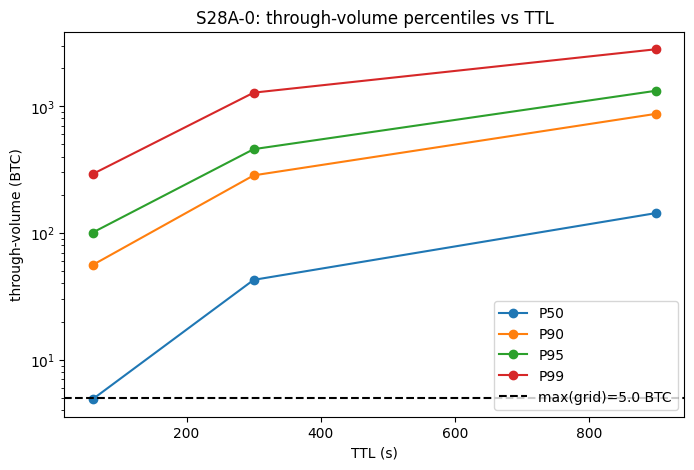

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for p in [50, 90, 95, 99]:
    ax.plot([t/1000 for t in TTL_CANDIDATES_MS], [results[t]["percentiles"][p] for t in TTL_CANDIDATES_MS],
            marker="o", label=f"P{p}")
ax.axhline(g_max, ls="--", color="k", label=f"max(grid)={g_max} BTC")
ax.set_xlabel("TTL (s)"); ax.set_ylabel("through-volume (BTC)"); ax.set_yscale("log"); ax.legend()
ax.set_title("S28A-0: through-volume percentiles vs TTL")
fig.savefig(OUT / "S28A_0_through_volume.png", dpi=120, bbox_inches="tight")
plt.show()

In [5]:
report = {
    "delta_ticks": 5, "order_qty": "0.01", "lambda_per_sec": LAMBDA_PER_SEC,
    "seed": SEED_EXPERIMENT, "sample_days": SAMPLE_DAYS, "grid_max": g_max,
    "results": {str(t): {"n_orders": r["n_orders"], "reach_rate": r["reach_rate"],
                          "percentiles": r["percentiles"], "verdict": r["verdict"]}
                for t, r in results.items()},
}
accepted = [t for t, r in results.items() if r["verdict"] == "ACCEPT"]
report["recommended_ttl_ms"] = min(accepted, key=lambda t: abs(t - 300_000)) if accepted else None
(OUT / "S28A_0_calibration.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
print("Recommended TTL:", report["recommended_ttl_ms"])
print("If recommended_ttl_ms is None: no candidate TTL accepts the current grid -> rescale grid per spec.")

Recommended TTL: 300000
If recommended_ttl_ms is None: no candidate TTL accepts the current grid -> rescale grid per spec.
